## 1: Nhập thư viện

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 2: Đọc dữ liệu, tách X feature và y lable

In [19]:
train_df = pd.read_csv("train_feature.csv")
test_df = pd.read_csv("test_feature.csv")
X_train = train_df.drop(columns=["Live AQI"])
y_train = train_df["Live AQI"]

X_test = test_df.drop(columns=["Live AQI"])
y_test = test_df["Live AQI"]
train_df.head()

,PM2.5,PM10,CO,SO2,NO2,Live AQI
0,1.011413,0.960810,0.979770,1.237371,0.575465,65.0
1,-0.325527,-0.671915,0.359511,-0.626812,-1.050064,35.0
2,-0.801823,-0.383366,-0.894230,-0.626812,0.033622,23.0
3,-1.117696,-0.671915,-0.976525,-0.626812,-0.508221,15.0
4,-0.801823,-0.671915,0.550804,-0.626812,-1.320986,20.0


## 3: Lý thuyết mô hình: Ridge Regression (Hồi quy Ridge)

### 🧠 3.1 Lý thuyết cơ bản
Ridge Regression là một mô hình hồi quy tuyến tính có thêm **regularization L2**, giúp ngăn mô hình học quá chi tiết vào dữ liệu huấn luyện (overfitting), đặc biệt khi có nhiều đặc trưng tương quan.
### 🎯 3.2 Hàm mất mát (Loss Function)

Hàm mục tiêu trong Ridge Regression kết hợp giữa lỗi dự đoán và penalty lên trọng số:

$$
J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{p} \theta_j^2
$$

- **MSE**: mean squared error giữa giá trị thực và giá trị dự đoán
- $\alpha$: hệ số điều chỉnh mức độ regularization
  - $\alpha = 0$: giống hồi quy tuyến tính thường
  - $\alpha \uparrow$: mức phạt tăng $\Rightarrow$ trọng số bị thu nhỏ $\Rightarrow$ mô hình đơn giản hơn, giảm overfitting

---
### 🧩 3.3 Các siêu tham số quan trọng

| Siêu tham số     | Ý nghĩa                                                                 |
|------------------|-------------------------------------------------------------------------|
| `alpha`          | Hệ số phạt L2. Giá trị lớn giúp giảm overfitting                       |
| `fit_intercept`  | Có nên học hệ số chệch (bias) hay không                               |
| `normalize`      | Có nên chuẩn hóa dữ liệu đầu vào trước khi huấn luyện không           |
| `solver`         | Thuật toán tối ưu để tìm nghiệm (`auto`, `saga`, `lsqr`, `svd`, ...)  |
| `max_iter`       | Số vòng lặp tối đa của thuật toán tối ưu                              |

---



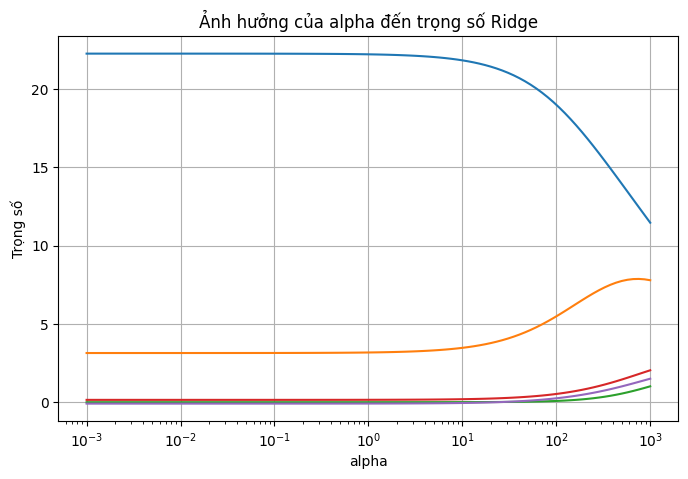

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 3, 100)
coefs = []

for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=True)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

plt.figure(figsize=(8, 5))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Trọng số")
plt.title("Ảnh hưởng của alpha đến trọng số Ridge")
plt.grid(True)
plt.show()


## 4. Huấn luyện mô hình

In [21]:
from sklearn.linear_model import Ridge

# Khởi tạo mô hình với alpha ban đầu = 1.0
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)


Ridge()

## 5. Dự đoán và đánh giá mô hình

### Dùng hai chỉ số:

- **RMSE (Root Mean Squared Error)**: đo sai số trung bình dự đoán
    - Càng nhỏ càng tốt
- **R² score**: phần trăm phương sai của dữ liệu được mô hình giải thích
    - Gần 1 là tốt, < 0 là mô hình kém hơn trung bình


In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")



RMSE: 3.37
R² Score: 0.9819


## 6. Tìm tham số Anpha với GridSearchCV
### Lý do dùng GridSearchCV:

- Tự động thử nhiều giá trị `alpha`
- Đánh giá hiệu suất qua kiểm thử chéo (cross-validation)
- Trả về mô hình có alpha tốt nhất (tối thiểu hóa MSE)


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = Ridge()

# Dùng 5-fold cross-validation
grid_search = GridSearchCV(ridge, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Kết quả
print("Best alpha:", grid_search.best_params_['alpha'])
print("Best CV score (negative MSE):", grid_search.best_score_)


Best alpha: 0.01
Best CV score (negative MSE): -12.61348051248493


## 7. Đánh giá lại với mô hình tốt nhất


In [24]:
# Huấn luyện lại với alpha tối ưu
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

# Tính RMSE theo cách thủ công để tránh lỗi squared=False
best_mse = mean_squared_error(y_test, y_best_pred)
best_rmse = np.sqrt(best_mse)

# Tính R² Score
best_r2 = r2_score(y_test, y_best_pred)

# In kết quả
print(f"[Optimal Alpha] RMSE: {best_rmse:.2f}")
print(f"[Optimal Alpha] R² Score: {best_r2:.4f}")


[Optimal Alpha] RMSE: 3.37
[Optimal Alpha] R² Score: 0.9819


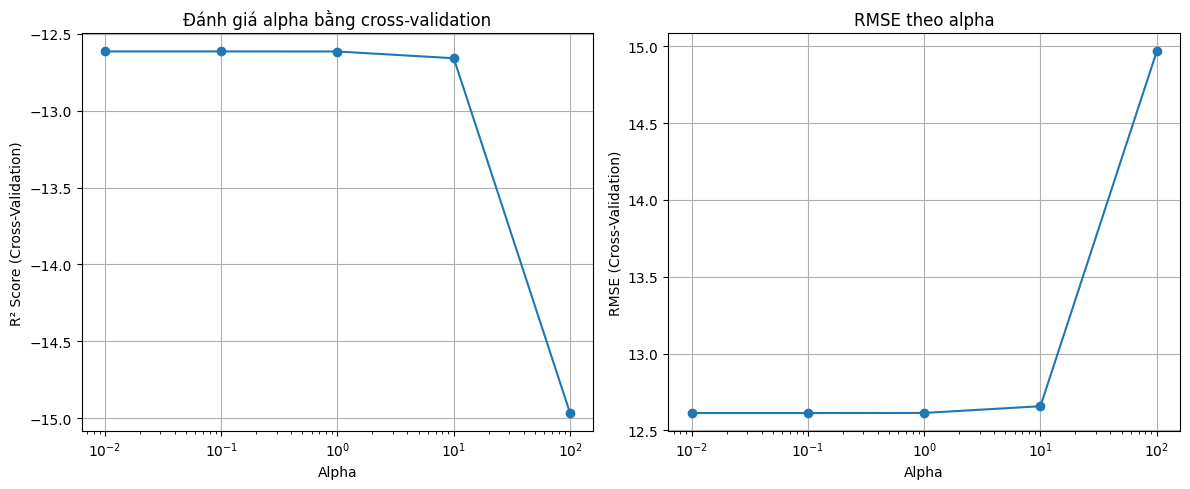

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Tạo DataFrame từ kết quả GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Tạo figure và hai subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: R² Score (Cross-Validation)
axes[0].plot(results["param_alpha"], results["mean_test_score"], marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R² Score (Cross-Validation)")
axes[0].set_title("Đánh giá alpha bằng cross-validation")
axes[0].grid(True)

# Subplot 2: RMSE (Cross-Validation)
axes[1].plot(results["param_alpha"], -results["mean_test_score"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("RMSE (Cross-Validation)")
axes[1].set_title("RMSE theo alpha")
axes[1].grid(True)

# Hiển thị cả hai biểu đồ
plt.tight_layout()
plt.show()

## Tổng kết
- Ridge Regression giúp cải thiện độ ổn định của hồi quy tuyến tính khi có đa cộng tuyến.
- Alpha là tham số regularization – cần chọn cẩn thận qua kiểm thử chéo.
- RMSE và R² là chỉ số phổ biến để đánh giá chất lượng dự đoán.
- GridSearchCV giúp chọn hyperparameter tốt nhất một cách hệ thống.
